In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from numpy import exp as exp
import scipy.io as sio

# vATPase function

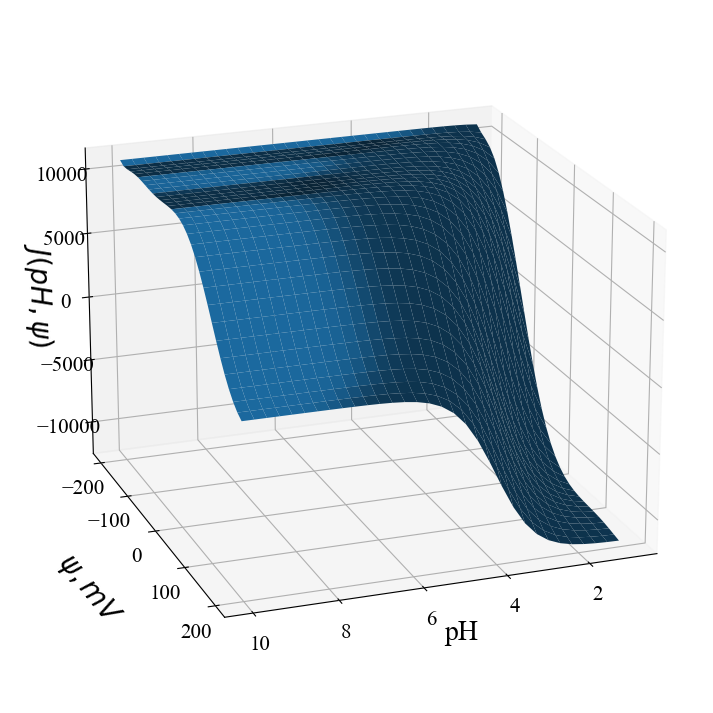

In [2]:
# @jit
def J_v(pH_L, psi):
    
    psi_start, psi_end = -300, 300
    pH_start, pH_end = 0, 9
    
    if (pH_L < pH_start):
        pH_L = pH_start
    elif (pH_L > pH_end):
        pH_L = pH_end
    
    if (psi < psi_start):
        psi = psi_start
    elif (psi > psi_end):
        psi = psi_end
    
    p_a = 3.3654e-24*psi**10+-1.72718633e-21*psi**9+-1.88006118e-19*psi**8+1.84428806e-16*psi**7+1.14875767e-15*psi**6+-7.86180209e-12*psi**5+8.73621142e-11*psi**4+1.38612359e-07*psi**3+4.02706504e-06*psi**2+-0.000921991562*psi**1+0.892742811*psi**0
    p_b = -0.01183303*psi**1+-1.74410965*psi**0
    p_c = 1.97927106e-17*psi**8+-8.11163955e-15*psi**7+-1.41331765e-12*psi**6+7.37414295e-10*psi**5+2.69242151e-08*psi**4+-1.47727446e-05*psi**3+-0.0018809272*psi**2+0.0294192901*psi**1+122.27226*psi**0
    p_d = 3.32575786e-13*psi**6+-3.43339599e-11*psi**5+-5.76545216e-08*psi**4+7.89631331e-06*psi**3+0.00138326473*psi**2+0.11950506*psi**1+1.50734239*psi**0
    
    
    J = np.tanh(p_a*pH_L + p_b)*p_c-p_d
    return J*550/6

x = np.outer(np.linspace(1, 10, 32), np.ones(32))
y = np.outer(np.linspace(-200, 200, 32), np.ones(32)).T
z = np.vectorize(J_v)(x, y)



 
# Creating figure
fig = plt.figure(figsize = (14, 9))
plt.rc('font', family='Times New Roman')
ax = plt.axes(projection ='3d')

# Creating plot
ax.plot_surface(x, y, z)
ax.view_init(20, 70)
plt.xlabel(r'pH', fontsize = 20)

plt.ylabel(r'$\psi, mV$', fontsize = 20, labelpad=20)
plt.xticks(fontsize = 15)
y_ticks = np.arange(-200, 201, 100)
plt.yticks(y_ticks, fontsize=15)
font = {'size': 15}
ax.tick_params('z', labelsize=font['size'])
#make zlabel another font 'Times new roman'ArithmeticError
z_label = ax.set_zlabel(r'$J(pH, \psi)$', fontsize=20, rotation=60)
plt.savefig('figs_TMEM165/Approx_vATPase.png')


# show plot
plt.show()

# Constants and initial value

In [4]:
# Physical constants
F = 96485      #[C] Na*e
NA = 6.02e+23   # Avogadro constant [Particles/mol]
RTF = 26.72        #RT/F [mV]} 

# Lysosome sizes
init_R = 0.34            #organelle radius [microns]
init_V = (4/3*3.1416*init_R**3*1e-12)/1000 #{surface area [cm**2]}
init_S = 4*3.1416*init_R**2*1e-8 #{lysosome volume  [liters]}

# cytosolic initial concentrations and pH
Ca_C = 1e-07      #[M]
Cl_C = 0.05      #[M]
Na_C = 0.015      #[M]
K_C = 0.145      #[M]
pH_C = 7.2     



# Selective ion transporters settings
# Stoichiometries of ion transporters
TMEM165_Ca = 1       # Calcium stoichiometry of TMEM165
TMEM165_H = 3        # Proton stoichiometry of TMEM165
CLC_Cl = 2       # Chloride stoichiometry of ClC-7
CLC_H = 1        # Proton stoichiometry of ClC-7

# Activities of ion transporters

N_CLC = 50      #Number of ClC-7 []
N_TPC = 38 #by patch 
N_TMEM = 1



init_Aeff = 0.3 #Initial effective activity of ClC-7
q = 2.2         # Coefficient for ClC-7
r = 0.1         #Deactivation to activation ratio for ClC-7
tau_act = 1     #Activation time for ClC-7 [s]
tau_deact = 0.25     #Activation time for ClC-7  for ClC-7 [s]
N_VATP = 6     #Number of vATPases []
N_NKA = 13000    #"Activity" of NKA []
p = 3.88e-12     #TRPML1 coefficient []

# Lysosome membrane permeabilities
P_Ca = 1.49e-7      #[ion*cm/s]
P_Cl = 1.2e-5       #[ion*cm/s]
P_H = 6e-05      #[ion*cm/s]
P_K = 7.1e-7 *1.6     #[ion*cm/s]
P_Na = 9.6e-7*686/1000      #[ion*cm/s]
Pw = 0.054e-2   #water permeability

# lysosome physical properties
beta_pH = 0.04      #[M/pH] Proton buffering capacity
cap = 1.45267584e-14      #[Farad] 
cap_0 = 1e-06      #[F/cm^2] membrane Bilayer capacitance 

# lysosome initial concentrations, potential and pH
init_Ca_F = 0.0005      #[M]
init_Ca_T = 0.005      #[M]
init_Cl = 0.1  #[M]
init_pH = 4.7
init_H = 0.05     #[M]
init_K = 0.07   #[M]
init_Na = 0.010   #[M]

psi_in = 0       #potential [mV]
psi_out = -50    #potential [mV]
# B is the concentration of Donnan particles, 
B = init_K+init_Na+init_H-init_Cl  + init_Ca_T*2 - cap/F/init_V*(psi_in - psi_out) 


      


# Osmolarities
Oc = 0.291
oh =  0.73
ok =  0.73
ona = 0.73
ocl = 0.73
Q = init_V*(Oc - (oh*10**(-init_pH) + ok*init_K + ona*init_Na + ocl*init_Cl))

# Deriviatives

In [8]:
# @jit
def derivatives(X, t, stress = 'No', ind_vATPase = 1):
    '''
    compute derivatives of X wrt time
    '''
    Aeff, NH, pH, NK, NNa, NCl, NCa_T, NCa_F, R = X

    N_VATP = 7
    N_CAX = 16
    p = 3.88e-12

    P_Ca = 1.49e-7      #[ion*cm/s]
    P_Cl = 1.2e-5       #[ion*cm/s]
    P_H = 6.2e-05      #[ion*cm/s]
    P_K = 7.1e-7 *1.6     #[ion*cm/s]
    P_Na = 9.6e-7*686/1000      #[ion*cm/s]
    Pw = 0.054e-2   #water permeability

    pure_basefication = 0


    if stress == 'Permeabilization10':
        if ((t>800) and (t<1500)):
            n_per = 10
            P_Ca = 1.49e-7*686/1000 *n_per        #[ion*cm/s]
            P_Cl = 1.2e-5*n_per       #[ion*cm/s]
            P_H = 6e-05*n_per        #[ion*cm/s]
            P_K = 7.1e-7*1.6 *n_per        #[ion*cm/s]
            P_Na = 9.6e-7*n_per   
            Pw = 0.054e-2*n_per  
        
        else:
            P_Ca = 1.49e-7      #[ion*cm/s]
            P_Cl = 1.2e-5       #[ion*cm/s]
            P_H = 6.2e-05      #[ion*cm/s]
            P_K = 7.1e-7 *1.6     #[ion*cm/s]
            P_Na = 9.6e-7*686/1000      #[ion*cm/s]
            Pw = 0.054e-2 



    if stress == 'Permeabilization100':
        if ((t>800) and (t<1500)):
            n_per = 100
            P_Ca = 1.49e-7*686/1000 *n_per        #[ion*cm/s]
            P_Cl = 1.2e-5*n_per       #[ion*cm/s]
            P_H = 6e-05*n_per        #[ion*cm/s]
            P_K = 7.1e-7*1.6 *n_per        #[ion*cm/s]
            P_Na = 9.6e-7*n_per   
            Pw = 0.054e-2*n_per  
        
        else:
            P_Ca = 1.49e-7        #[ion*cm/s]
            P_Cl = 1.2e-5       #[ion*cm/s]
            P_H = 6e-05      #[ion*cm/s]
            P_K = 7.1e-7      #[ion*cm/s]
            P_Na = 9.6e-7 
            Pw = 0.054e-2


        
        
    if stress == 'Ca_v':
        if (t>2000):
            N_VATP = 1
        else:
            N_VATP = 7

    if stress == 'Ca_al':
        pure_basefication = int((t>=2000))*5.12e4
     
    
    V = (4/3*3.1416*abs(R)**3*1e-12)/1000
    S = 4*3.1416*abs(R)**2*1e-8


    #Luminal Concentrations
    H = NH/V/NA
    K = NK/V/NA
    Na = NNa/V/NA
    Cl = NCl/V/NA
    Ca_F = NCa_F/V/NA
    Ca_T = NCa_T/V/NA
    r = Ca_F/Ca_T

    
    #membrane potential
#     psi = (F/cap)*init_V*(H + K + Na - Cl + 2*Ca_T - B)
    psi = (F/cap)*(V*(H + K + Na - Cl + 2*Ca_T) - B*init_V)


#      Modified Cytoplasmic Surface Concentrations
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    K_C0    = K_C*exp(-psi_out/RTF)
    Na_C0   = Na_C*exp(-psi_out/RTF) 
    Cl_C0   = Cl_C*exp(psi_out/RTF) 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    
#     Modified Luminal Surface Concentrations
    pH_L0   = (pH+psi_in/(RTF*2.3))
    K_L0    = K*exp(-psi_in/RTF)
    Na_L0   = Na*exp(-psi_in/RTF) 
    Cl_L0   = Cl*exp(psi_in/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 

    delta_pH    = pH_C0-pH_L0;  

#     Treatment of singular terms for passive ion flux
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)


        

    # vAPTase
    J_VATPASE  = N_VATP * J_v(pH, psi) * ind_vATPase


        # ClC-7 Antiporter {H out, Cl in}
    CLC_mu      = (CLC_H + CLC_Cl)*psi + RTF*(CLC_H*2.3*delta_pH + CLC_Cl*np.log(Cl_C0/Cl_L0))
    
    #     Switching function   
    x = 0.5 + 0.5*np.tanh((CLC_mu + 250)/75); 
    # Activity
    A = 0.3*x + 1.5E-5*(1-x)*CLC_mu**2;
    
    if (A < Aeff):
        tau = tau_deact
    else:
        tau = tau_act
        
    J_CLC    = N_CLC*Aeff*CLC_mu 
    
    

    
    
    
    
#      Passive flux [ion/s]
    J_H = P_H*S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000
    J_K = P_K*S*(K_C0*exp(-psi/RTF)-K_L0)*gg*NA/1000 #this is TMEM
    J_Na = P_Na*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    J_Cl_unc = P_Cl*S*(Cl_C0-Cl_L0*exp(-psi/RTF))*gg*NA/1000
    J_Ca = P_Ca*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000
    


    
    #water flux
    J_w = Pw*S*(oh*10**(-pH) + ok*K + ona*Na + ocl*Cl + Q/V - Oc)
    
#     TRPML1 channel
    y = 0.5 - 0.5*np.tanh(psi + 40)
    P_trpml1 = p*(y*abs(psi) + (1-y)*(abs (psi + 40)**3)/(pH_L0**q))
    J_Ca_trpml1 = P_trpml1*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000

  


    #   TPC {Na out}
    
    xh = 6.7e3*exp(-0.9*pH) - 15
    k = 11.3*pH**2 - 116.5*pH + 325.3
    P_TPC = 1/(1+exp((xh-psi)/k))
    J_TPC = N_TPC*P_TPC*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000


    if stress == 'Fast_vastpase_stress':
        if (t>500 and t<850):
            J_VATPASE = 0

    if stress == 'Fast_swelling':
        if (t>500 and t<850):
            J_w += 1e-13
            
            
    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2




    if NCa_T + (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)<=0:
        J_Ca = 0
        J_Ca_trpml1 = 0
        J_Ca_TMEM165 = 0
        print('Ca concentration is too close to negative')

    # if (NCa_F + (J_Ca + (CAX_Ca*J_CAX) + J_Ca_trpml1)*r)<=0:
    #     J_Ca = 0
    #     J_CAX = 0
    #     J_Ca_trpml1 = 0
    #     print('!!')



    dxdt = [(1/tau)*(A - Aeff),
        (J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication), 
           (-(J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)/V/NA)/beta_pH,
           (J_K),
           (J_Na + J_TPC),
           (J_Cl_unc + (CLC_Cl*J_CLC)),
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1),
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)*r, 
           J_w/(1000*55)/(4*np.pi*(R/1e5)**2)*1e5]

    return dxdt

In [9]:
init_NH = init_H*init_V*NA;      #[ions]
init_NK = init_K*init_V*NA;       
init_NNa = init_Na*init_V*NA;    
init_NCl = init_Cl*init_V*NA;     
init_NCa_T = init_Ca_T*init_V*NA; 
init_NCa_F = init_Ca_F*init_V*NA; 

X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

In [10]:
init_pH = 4.2

init_NH = np.power(10, -init_pH)*init_V*NA;      #[ions]
init_NK = init_K*init_V*NA;       
init_NNa = init_Na*init_V*NA;    
init_NCl = init_Cl*init_V*NA;     
init_NCa_T = init_Ca_T*init_V*NA; 
init_NCa_F = init_Ca_F*init_V*NA; 

X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

tspan = np.arange(0, 600, 1e-2)
solution = odeint(derivatives, X0, tspan)

In [11]:
def set_plot_font_params():
    """
    Set the font parameters for all plots in the Matplotlib instance.
    """
    # Set the font family and style
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Times new roman']
    plt.rcParams['font.style'] = 'normal'

    # Set the font sizes
    plt.rcParams['axes.labelsize'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 20


In [12]:
set_plot_font_params()

In [13]:
def V_arr_def(solution):
    V_arr = (4/3*3.1416*solution[:, 8]**3*1e-12)/1000
    return V_arr

def Psi_arr_def(solution, V_arr):
    psi_arr = (F/cap)*(V_arr*(solution[:, 1]/V_arr/NA + solution[:, 3]/V_arr/NA + solution[:, 4]/V_arr/NA - solution[:, 5]/V_arr/NA + 2*solution[:, 6]/V_arr/NA) - B*init_V)
    return psi_arr
    
def J_w_arr_def(solution, V_arr):
    J_w_arr = Pw*4*3.1416*abs(solution[:, 8])**2*1e-8*(oh*10**(-solution[:, 2]) + ok*solution[:, 3]/V_arr/NA + ona*solution[:, 4]/V_arr/NA + ocl*solution[:, 5]/V_arr/NA + Q/V_arr - Oc)
    return J_w_arr

In [14]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

In [15]:
pH_list = []
R_list = []
vATPase_list = []
psi_list = []

pH_i = np.arange(4, 7.5, 0.3)
pH_i = np.append(pH_i, 4.7)



for init_pH_i in pH_i:
    init_pH = init_pH_i

    init_NH = np.power(10, -init_pH)*init_V*NA;      #[ions]
    init_NK = init_K*init_V*NA;       
    init_NNa = init_Na*init_V*NA;    
    init_NCl = init_Cl*init_V*NA;     
    init_NCa_T = init_Ca_T*init_V*NA; 
    init_NCa_F = init_Ca_F*init_V*NA; 

    X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

    tspan = np.arange(0, 600, 1e-2)
    solution = odeint(derivatives, X0, tspan)
    pH_list.append(solution[:, 2])
    R_list.append(solution[:, 8])
    v_arr = V_arr_def(solution)
    psi_arr = Psi_arr_def(solution, v_arr)
    psi_list.append(psi_arr)
    vATPase_list.append(np.vectorize(J_v)(solution[:, 2], psi_arr))

pH_i

array([4. , 4.3, 4.6, 4.9, 5.2, 5.5, 5.8, 6.1, 6.4, 6.7, 7. , 7.3, 4.7])

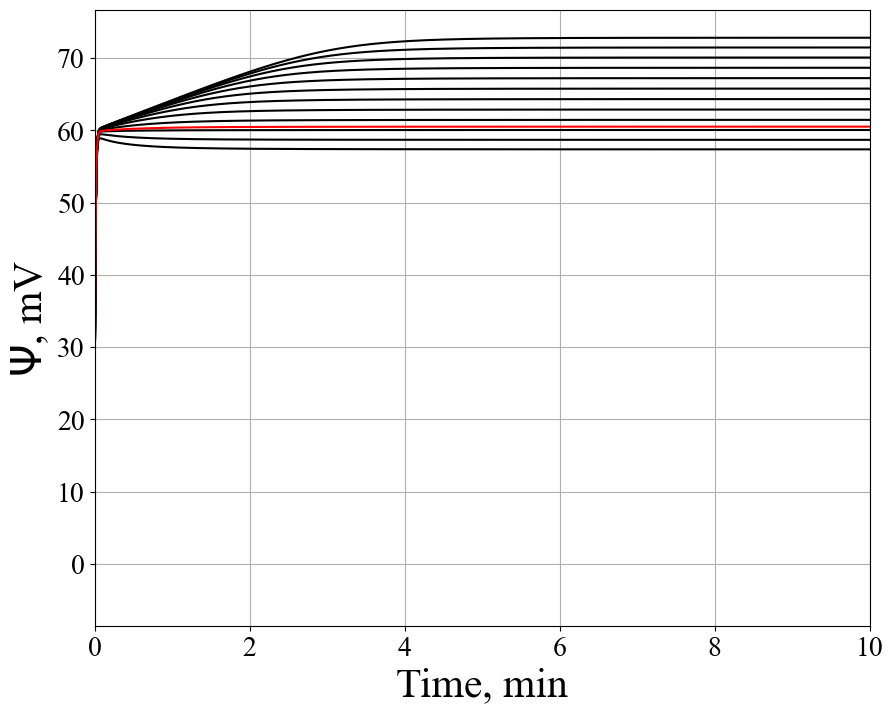

In [16]:
def plot_psi_list(t, psi_list, pH_i):
    plt.figure(figsize=(10, 8), dpi=100)
    t=t/60
    for i, psi_in_list in enumerate(psi_list):
        color_plot = 'black'
        if i == len(pH_i)-1:
            color_plot = 'red'
        plt.plot(t, psi_in_list,  color_plot, label=f'pH = {round(pH_i[i], 1)}')
    # plt.legend(loc='best', fontsize=30)
    plt.xlim(0, 10)
    plt.ylabel(r'$\Psi$, mV', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.savefig('figs/psi_dif_pH.png', dpi=300) 
    plt.show()

plot_psi_list(tspan, psi_list, pH_i)

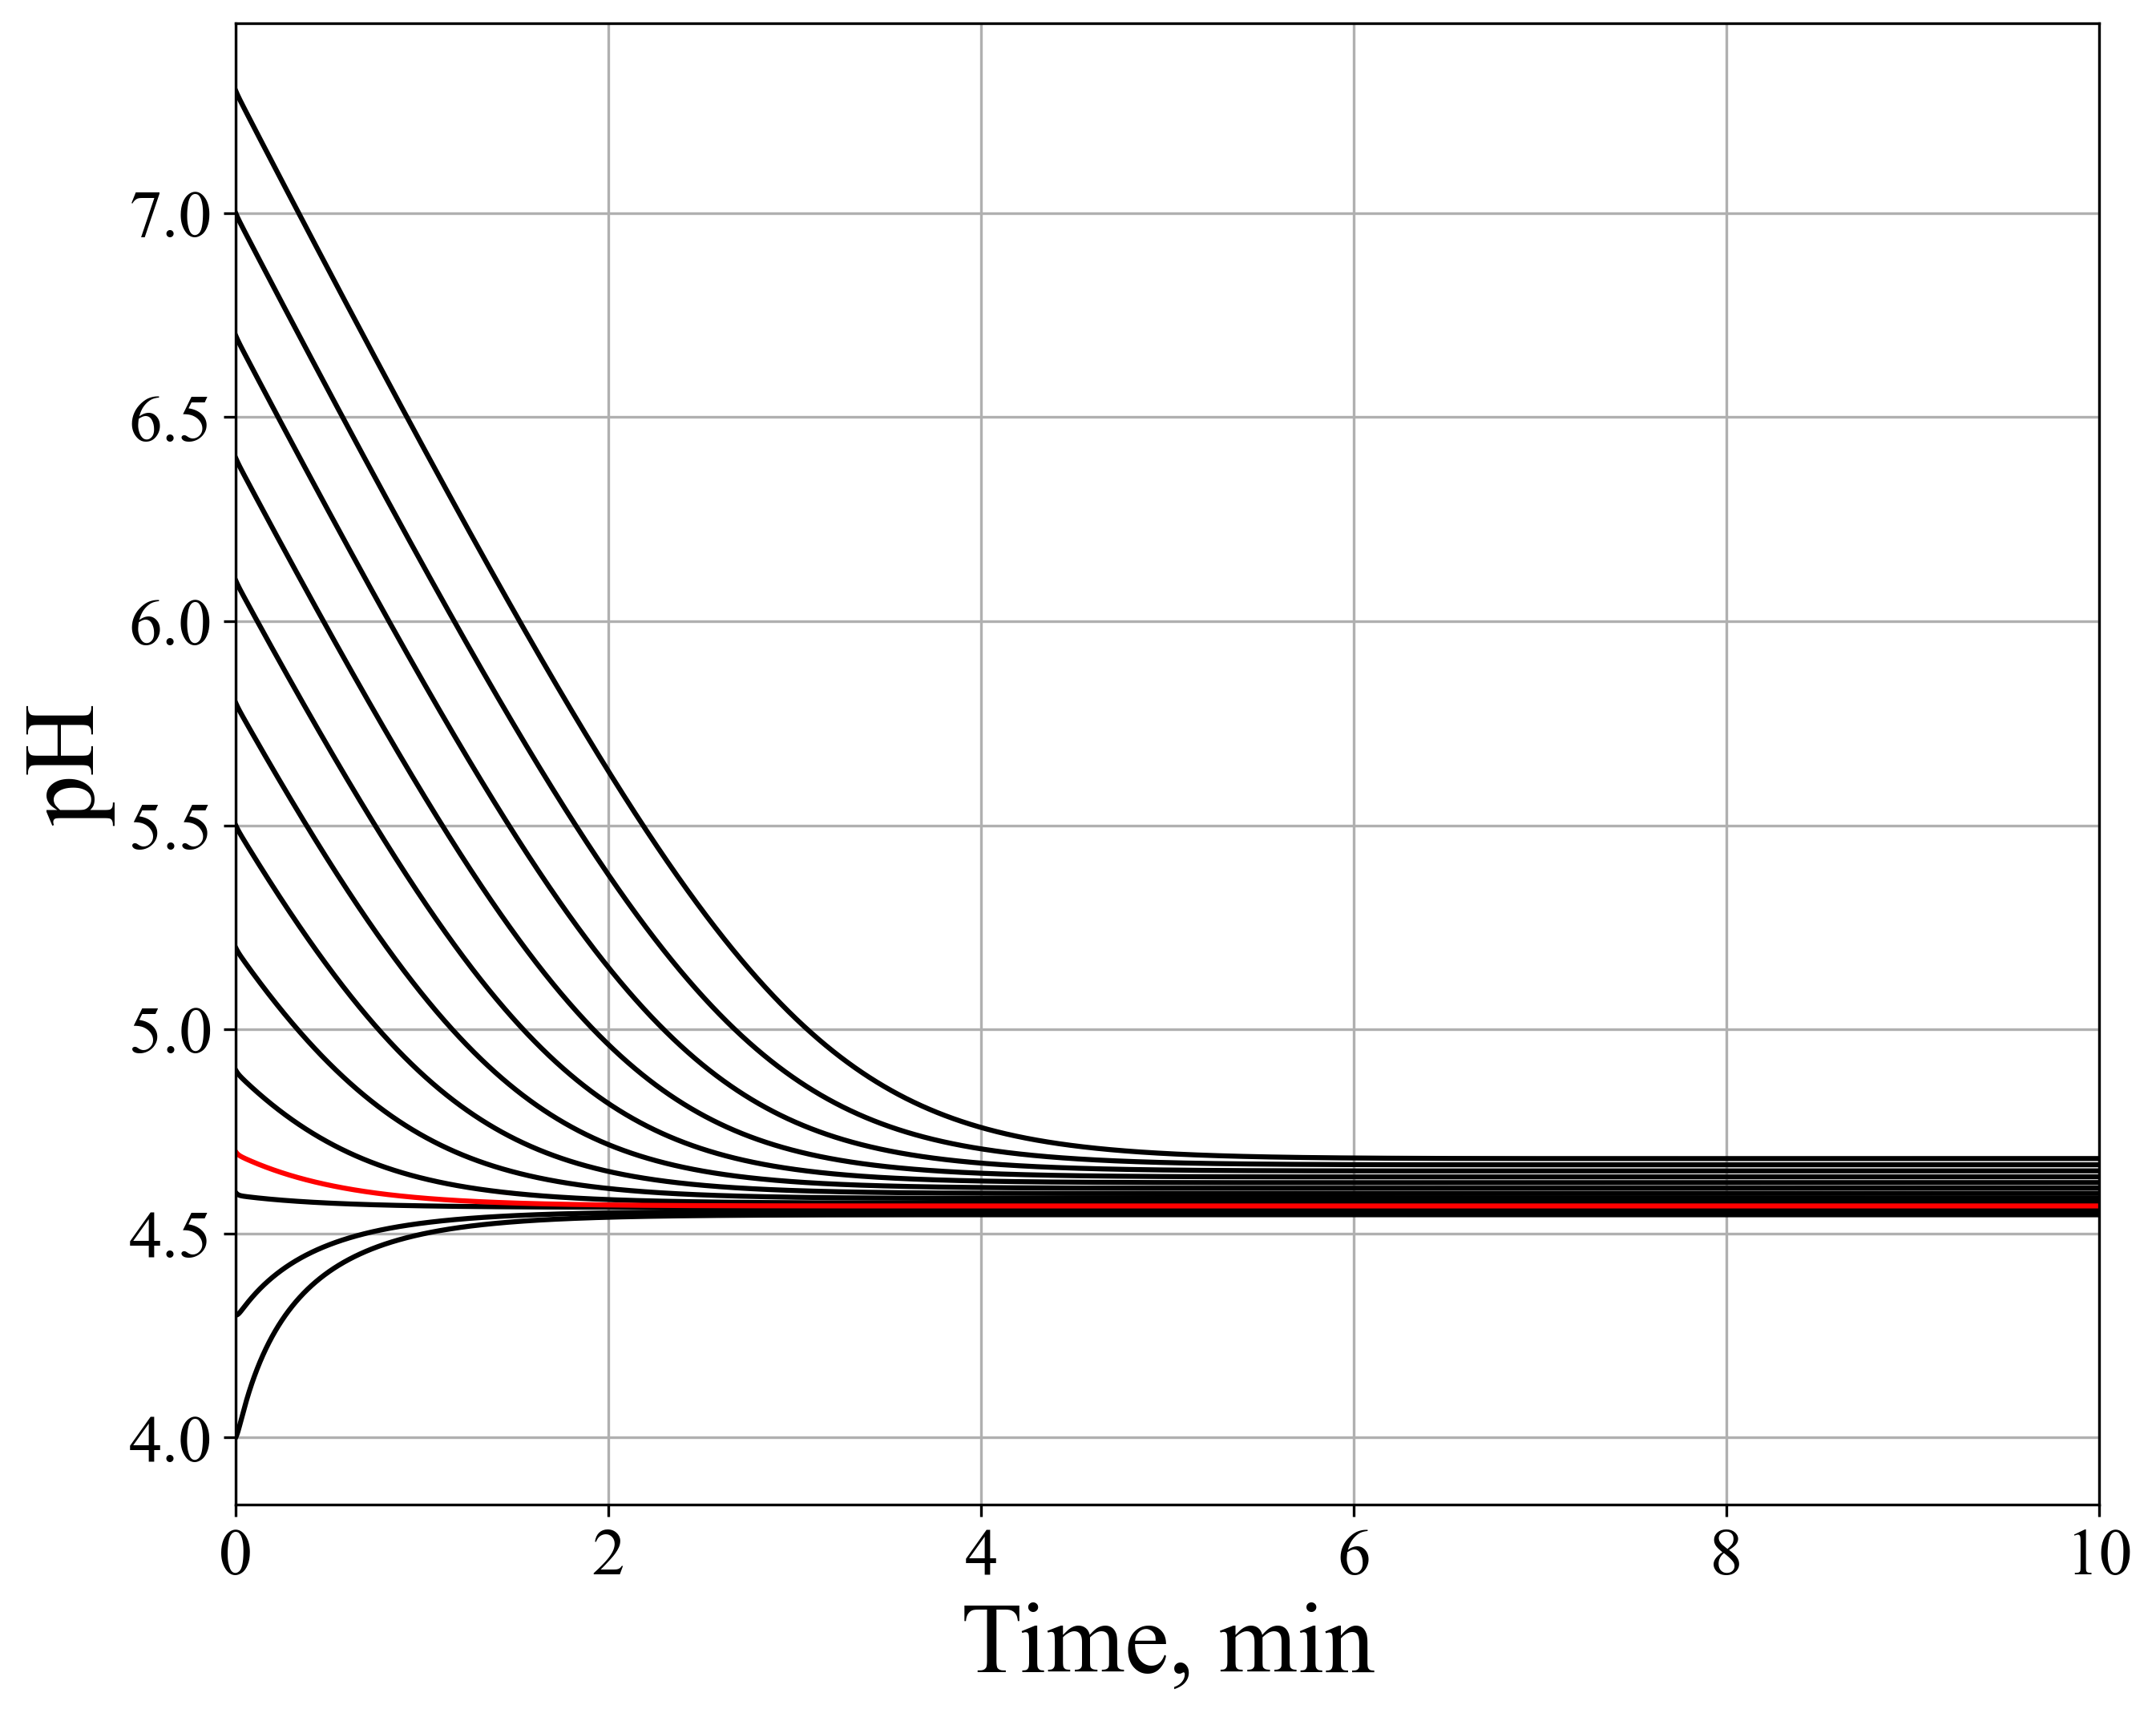

In [17]:
def plot_pH_list(t, pH_list, pH_i):
    plt.figure(figsize=(10, 8), dpi=300)
    t=t/60
    for i, pH_in_list in enumerate(pH_list):
        color_pH = 'black'
        if i == len(pH_i)-1:
            color_pH = 'red'
        plt.plot(t, pH_in_list, color_pH, label=f'pH = {round(pH_i[i], 1)}')

    plt.ylabel('pH', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.xlim(0, 10)
    plt.savefig('figs/pH_dif_pH.png', dpi=300)
    plt.show()

plot_pH_list(tspan, pH_list, pH_i)

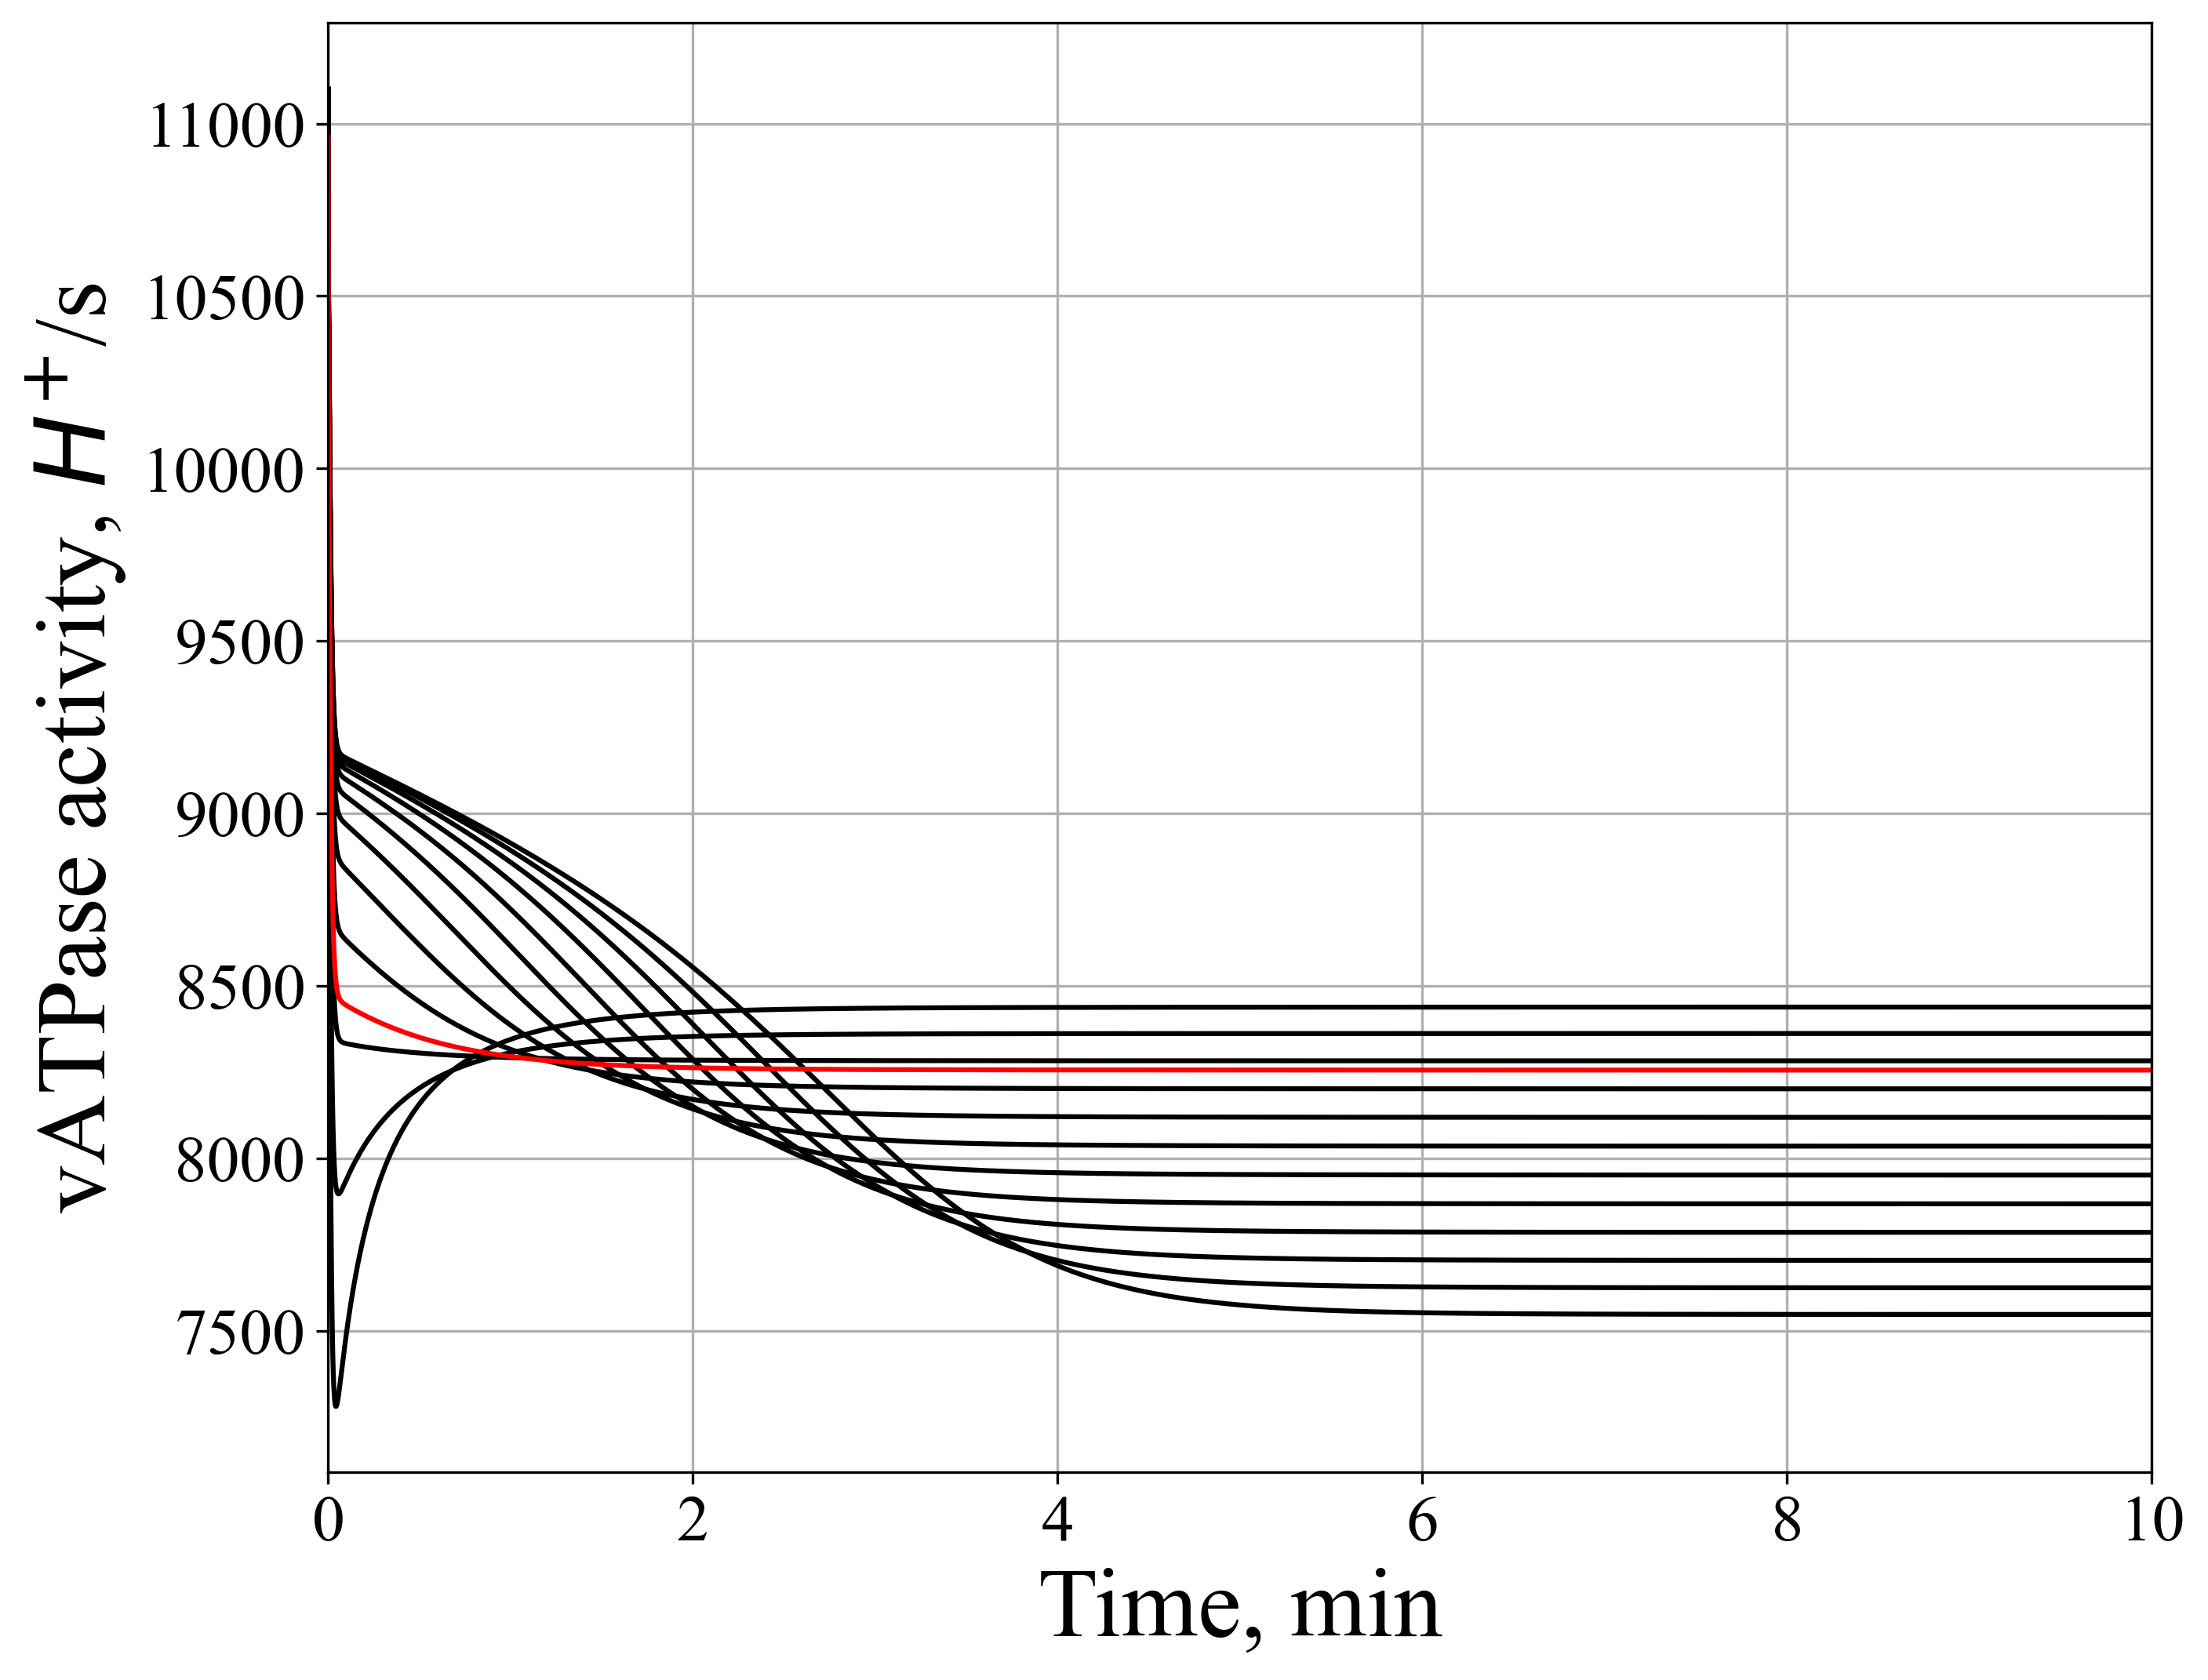

In [18]:
def plot_vATPase_list(t, vATPase, pH_i):
    plt.figure(figsize=(10, 8), dpi=300)
    t=t/60
    for i, vATPase_in_list in enumerate(vATPase_list):
        color_plot = 'black'
        if i == len(pH_i)-1:
            color_plot = 'red'
        plt.plot(t, vATPase_in_list,  color_plot, label=f'pH = {round(pH_i[i], 1)}')
    # plt.legend(loc='best', fontsize=30)
    plt.xlim(0, 10)
    plt.ylabel(r'vATPase activity, $H^{+}$/s', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)

    plt.grid()
    plt.savefig('figs/vATPase_dif_pH.png', dpi=300)

    plt.show()

plot_vATPase_list(tspan, vATPase_list, pH_i)

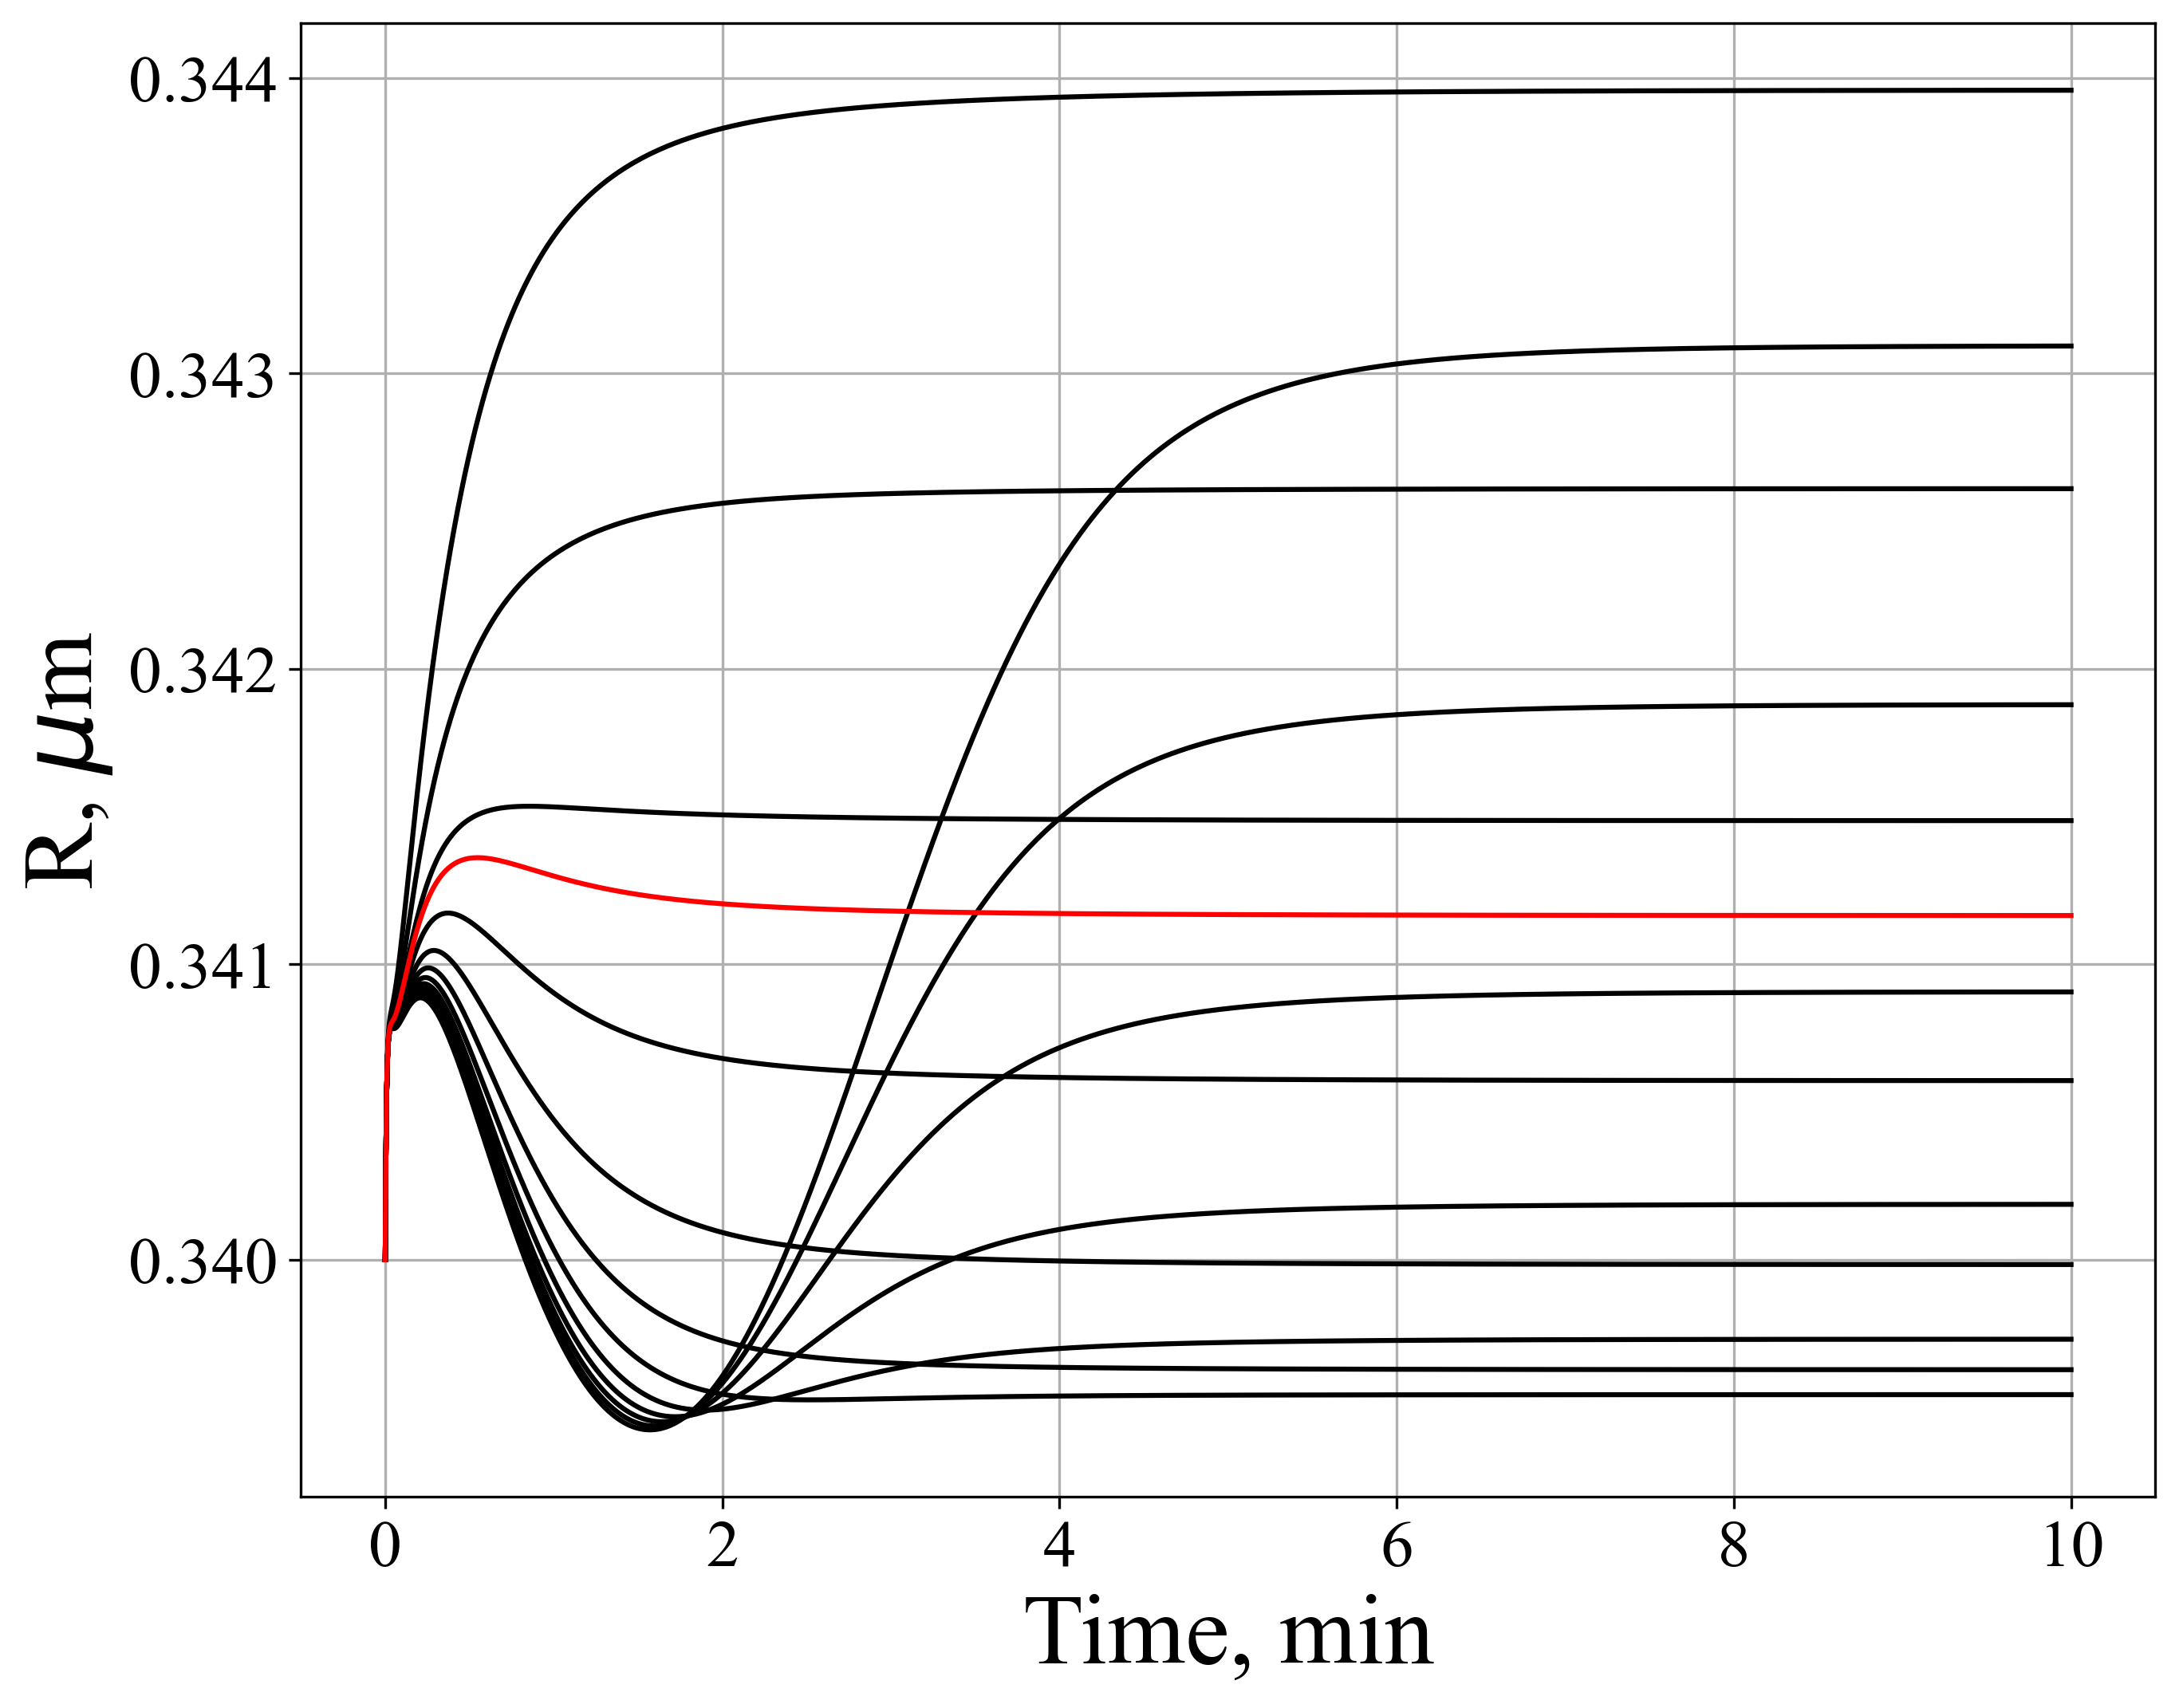

In [19]:
def plot_R_list(t, R_list, pH_i):
    plt.figure(figsize=(10, 8), dpi=300)
    t=t/60
    for i, R_in_list in enumerate(R_list):
        color_R = 'black'
        if i == len(pH_i)-1:
            color_R = 'red'
        plt.plot(t, R_in_list, color_R, label=f'pH = {round(pH_i[i], 1)}')

    plt.ylabel(r'R, $\mu$m', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.savefig('figs/R_dif_pH.png', dpi=300)

    plt.show()

plot_R_list(tspan, R_list, pH_i)

In [20]:
Na_list = []
pH_list = []
R_list = []
vATPase_list = []

# Na_i = np.arange(0.09-0.09*0.1, 0.09+0.09*0.1, 0.09*0.2/5)
Na_i = np.arange(10, 150, 10)/1000
Na_i = np.append(Na_i, 0.02)

for init_Na_i in Na_i:
    init_pH = 4.7

    init_NH = np.power(10, -init_pH)*init_V*NA;      #[ions]
    init_NK = init_K*init_V*NA;       
    init_NNa = init_Na_i*init_V*NA;    
    init_NCl = init_Cl*init_V*NA;     
    init_NCa_T = init_Ca_T*init_V*NA; 
    init_NCa_F = init_Ca_F*init_V*NA; 

    X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

    tspan = np.arange(0, 600, 1e-2)
    solution = odeint(derivatives, X0, tspan)
    v_arr = V_arr_def(solution)
    Na_list.append(solution[:, 4]/v_arr/NA)
    pH_list.append(solution[:, 2])
    R_list.append(solution[:, 8])
    psi_arr = Psi_arr_def(solution, v_arr)
    vATPase_list.append(np.vectorize(J_v)(solution[:, 2], psi_arr))



In [21]:
Na_i

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.02])

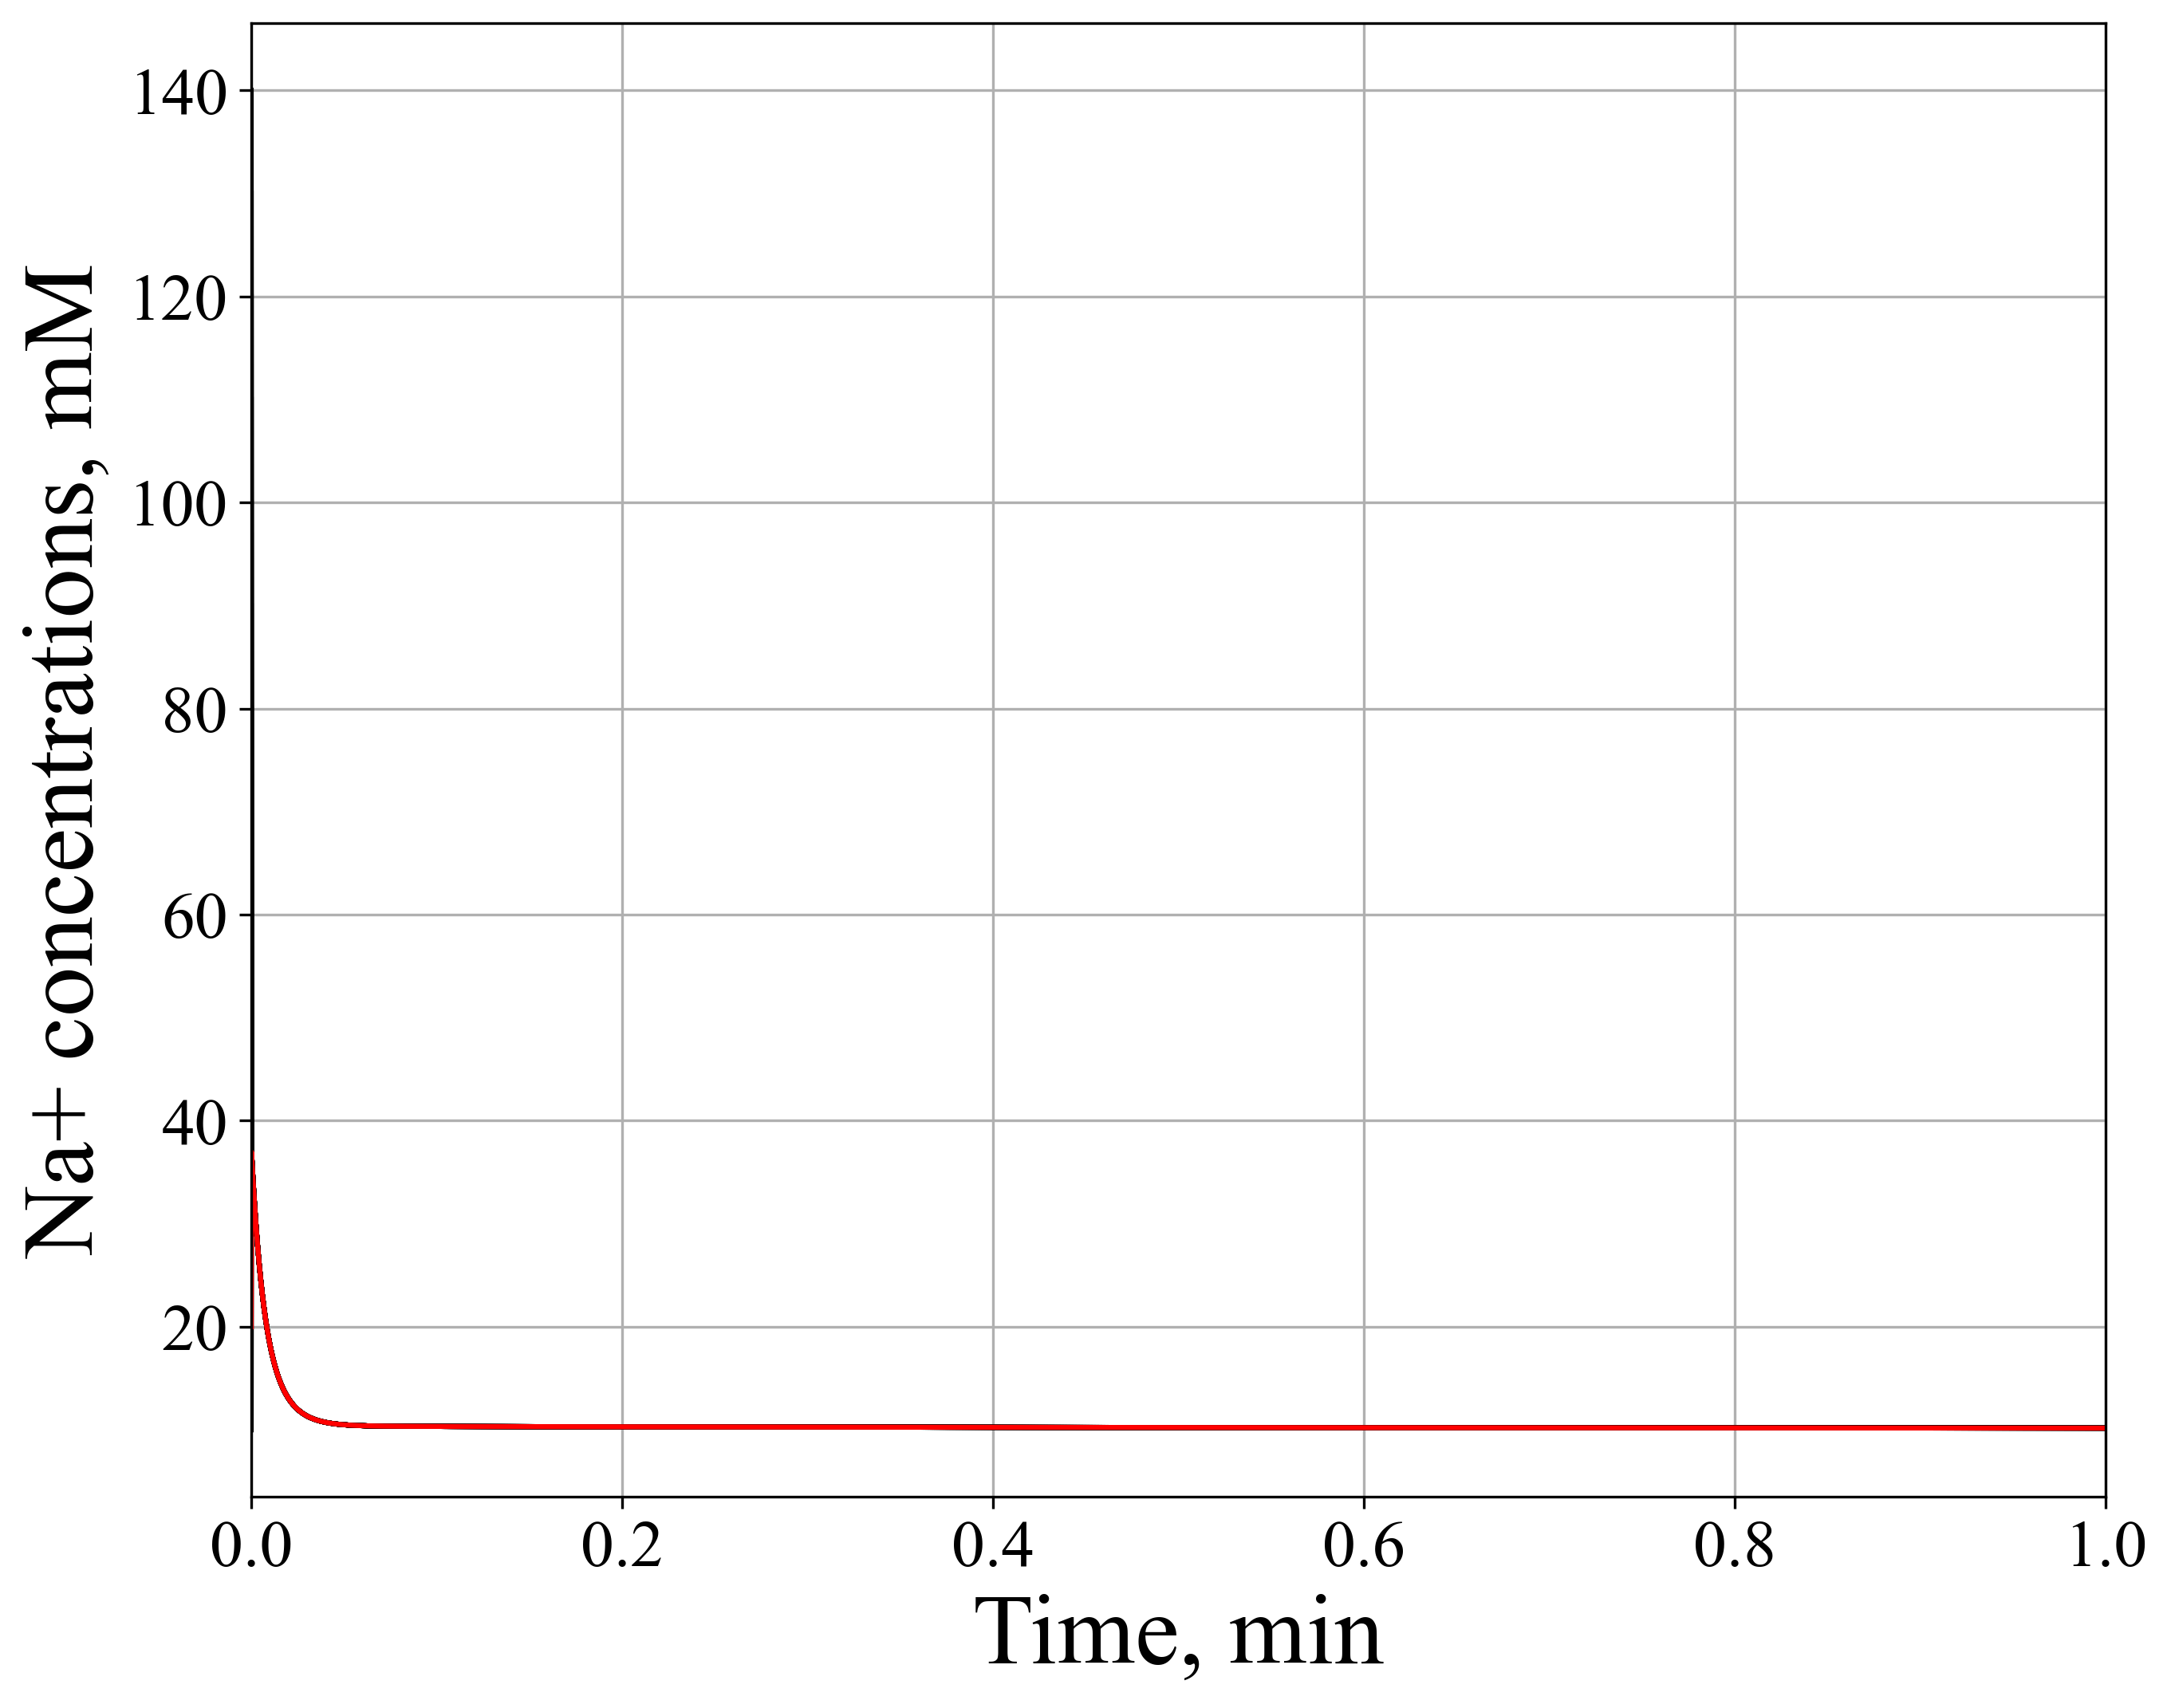

In [22]:
def plot_Na_list(t, Na_list, Na_i):
    t=t/60
    plt.figure(figsize=(10, 8), dpi=300)
    for i, Na_in_list in enumerate(Na_list):
        color_Na = 'black'
        if i == len(Na_i)-1:
            color_Na = 'red'
        plt.plot(t, Na_in_list*1000, color_Na, label=f'Na = {round(Na_i[i], 1)}')
    # plt.ylim(0, 1)
    plt.xlim(0, 1)

    plt.ylabel('Na+ concentrations, mM', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.savefig('figs/Na_dif_Na.png', dpi=300)
    plt.show()

plot_Na_list(tspan, Na_list, Na_i)

In [23]:
K_list = []
pH_list = []
R_list = []
vATPase_list = []

# Na_i = np.arange(0.09-0.09*0.1, 0.09+0.09*0.1, 0.09*0.2/5)
K_i = np.arange(5, 150, 20)/1000
K_i = np.append(K_i, 0.06)

for init_K_i in K_i:
    init_pH = 4.7
    init_Na = 0.09

    init_NH = np.power(10, -init_pH)*init_V*NA;      #[ions]
    init_NK = init_K_i*init_V*NA;       
    init_NNa = init_Na*init_V*NA;    
    init_NCl = init_Cl*init_V*NA;     
    init_NCa_T = init_Ca_T*init_V*NA; 
    init_NCa_F = init_Ca_F*init_V*NA; 

    X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

    tspan = np.arange(0, 600, 1e-2)
    solution = odeint(derivatives, X0, tspan)
    v_arr = V_arr_def(solution)
    K_list.append(solution[:, 3]/v_arr/NA)



In [24]:
len(K_i)-1

8

0 8
1 8
2 8
3 8
4 8
5 8
6 8
7 8
8 8
black


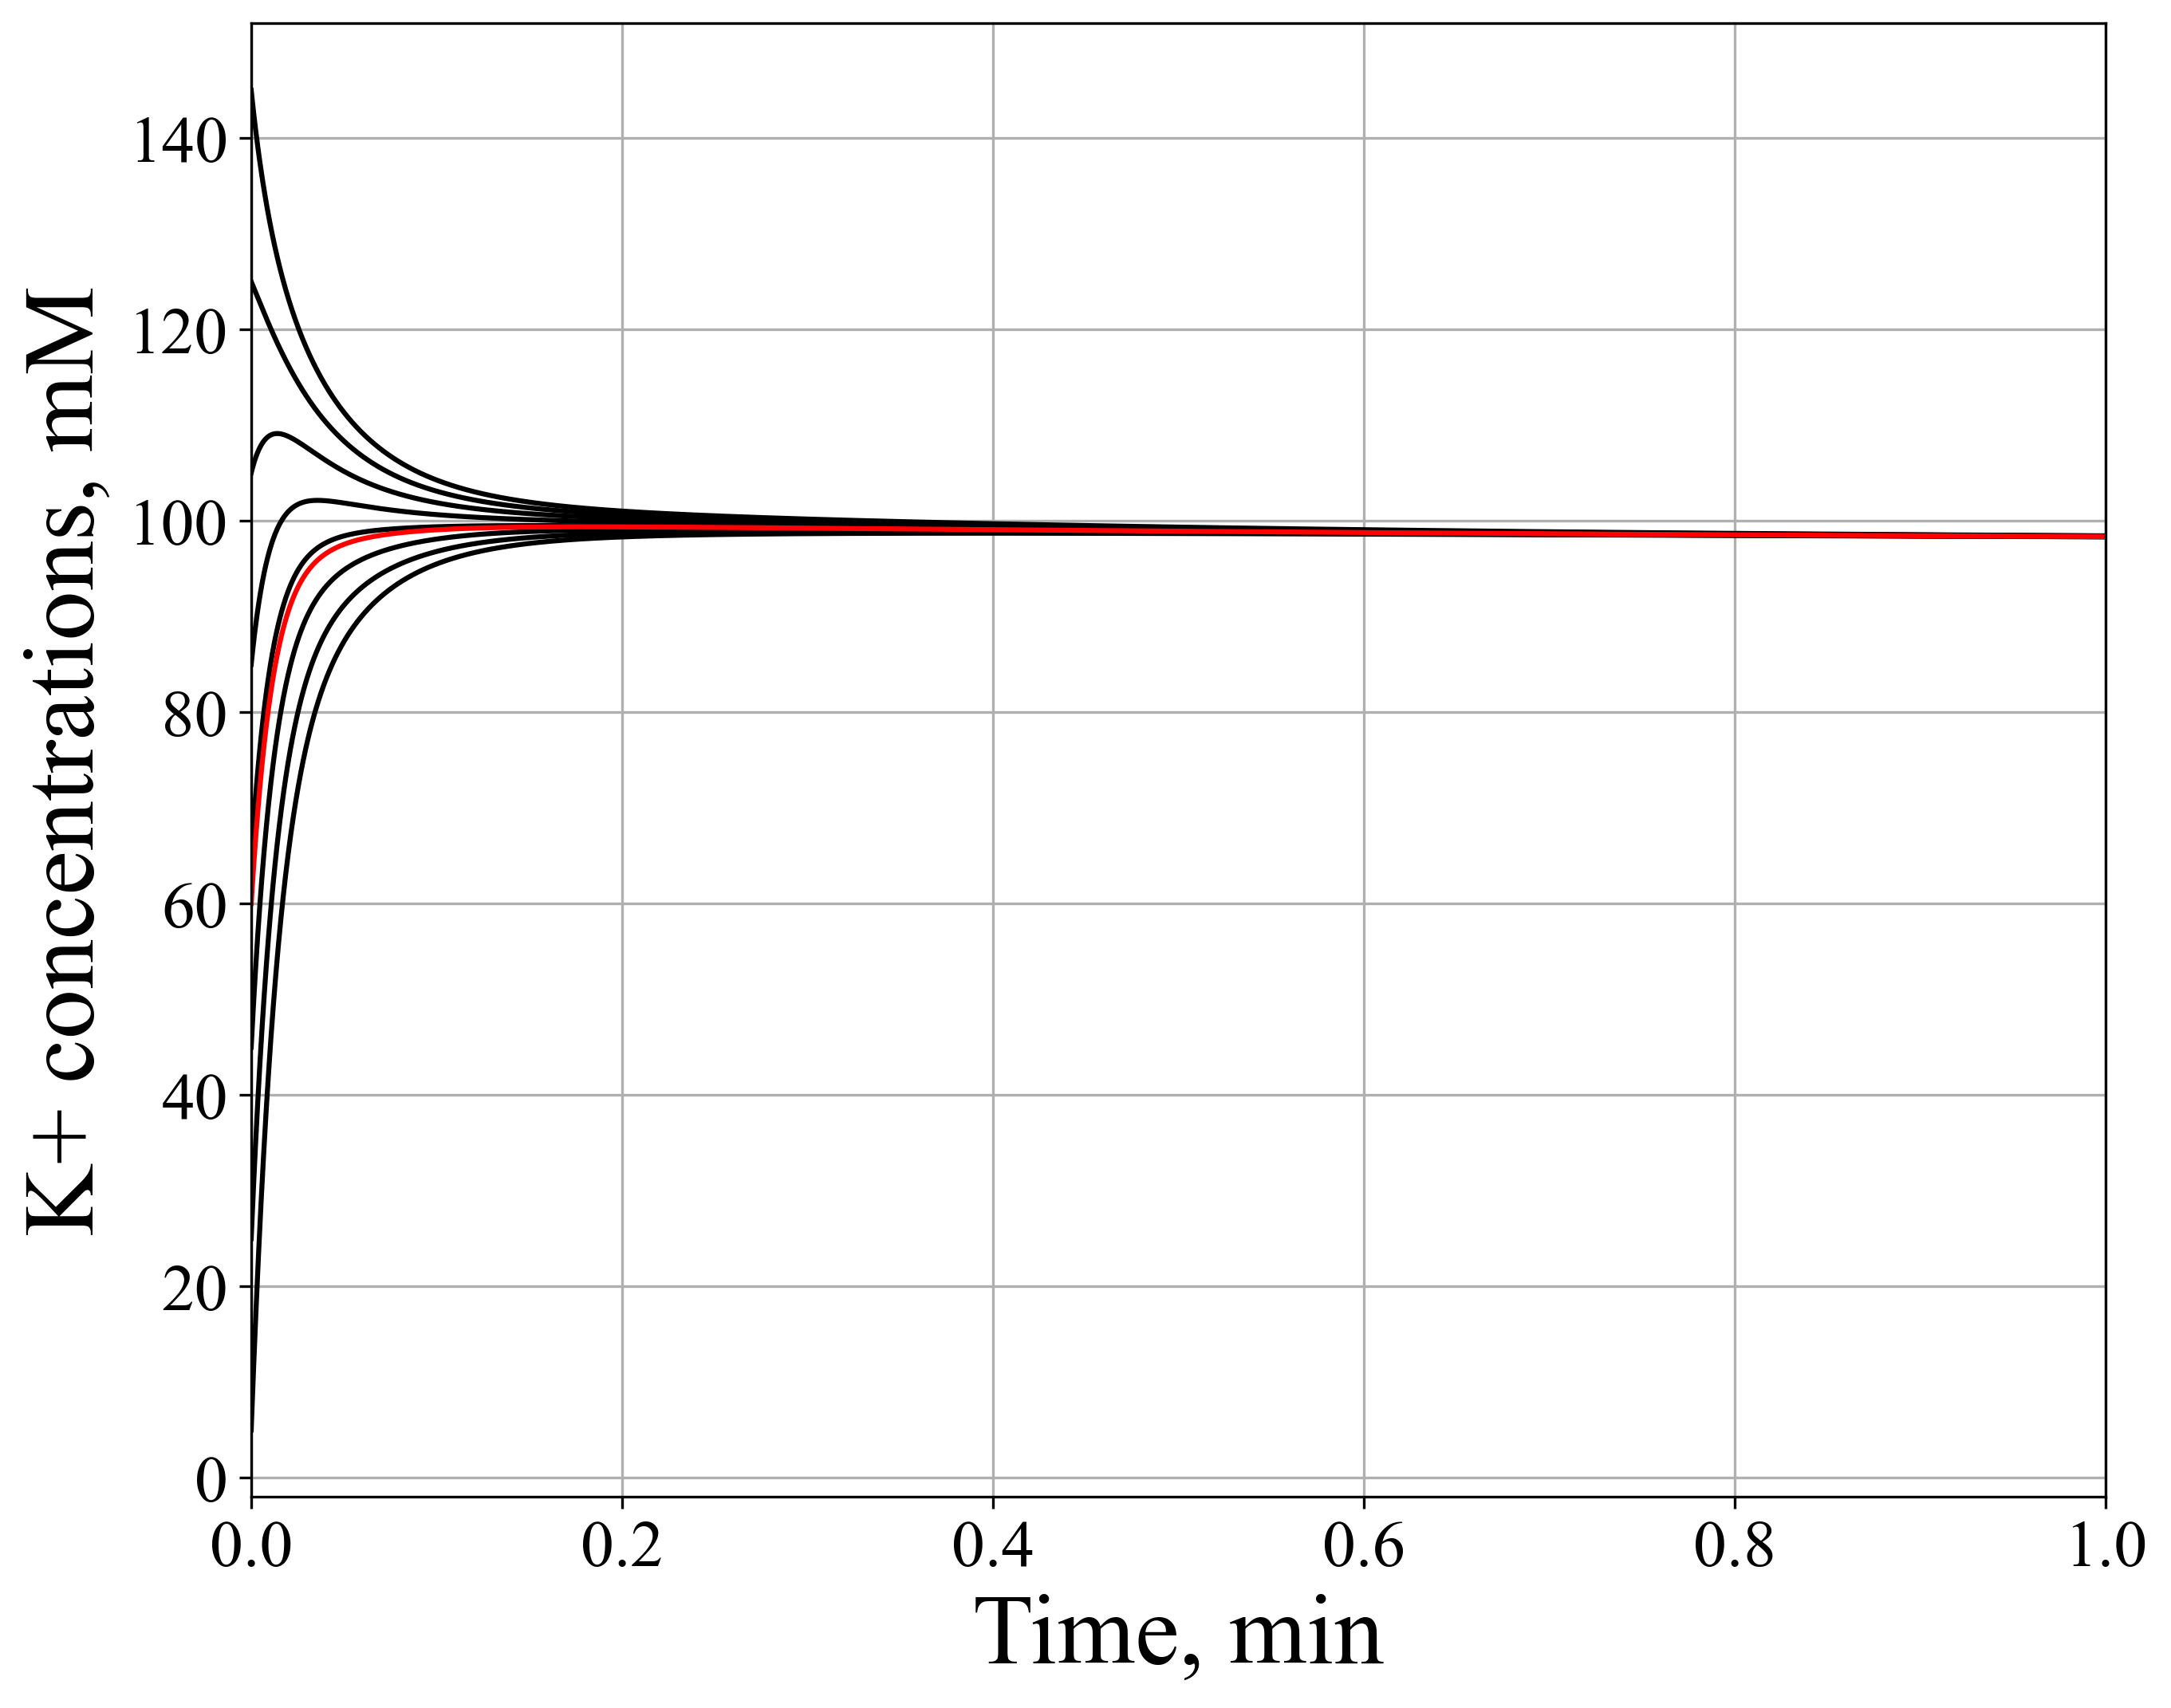

In [25]:
def plot_K_list(t, K_list, K_i):
    t=t/60
    plt.figure(figsize=(10, 8), dpi=300)
    for i, K_in_list in enumerate(K_list):
        color_K = 'black'
        print(i, len(K_i)-1)
        if (i == len(K_i)-1):
            print(color_K)
            color_K = 'red'
        plt.plot(t, K_in_list*1000, color_K, label=f'K = {round(K_i[i], 1)}')
    # plt.ylim(0.03825, 0.03875)
    plt.xlim(0, 1)

    plt.ylabel('K+ concentrations, mM', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.savefig('figs/K_dif_K.png', dpi=300)
    plt.show()

plot_K_list(tspan, K_list, K_i)

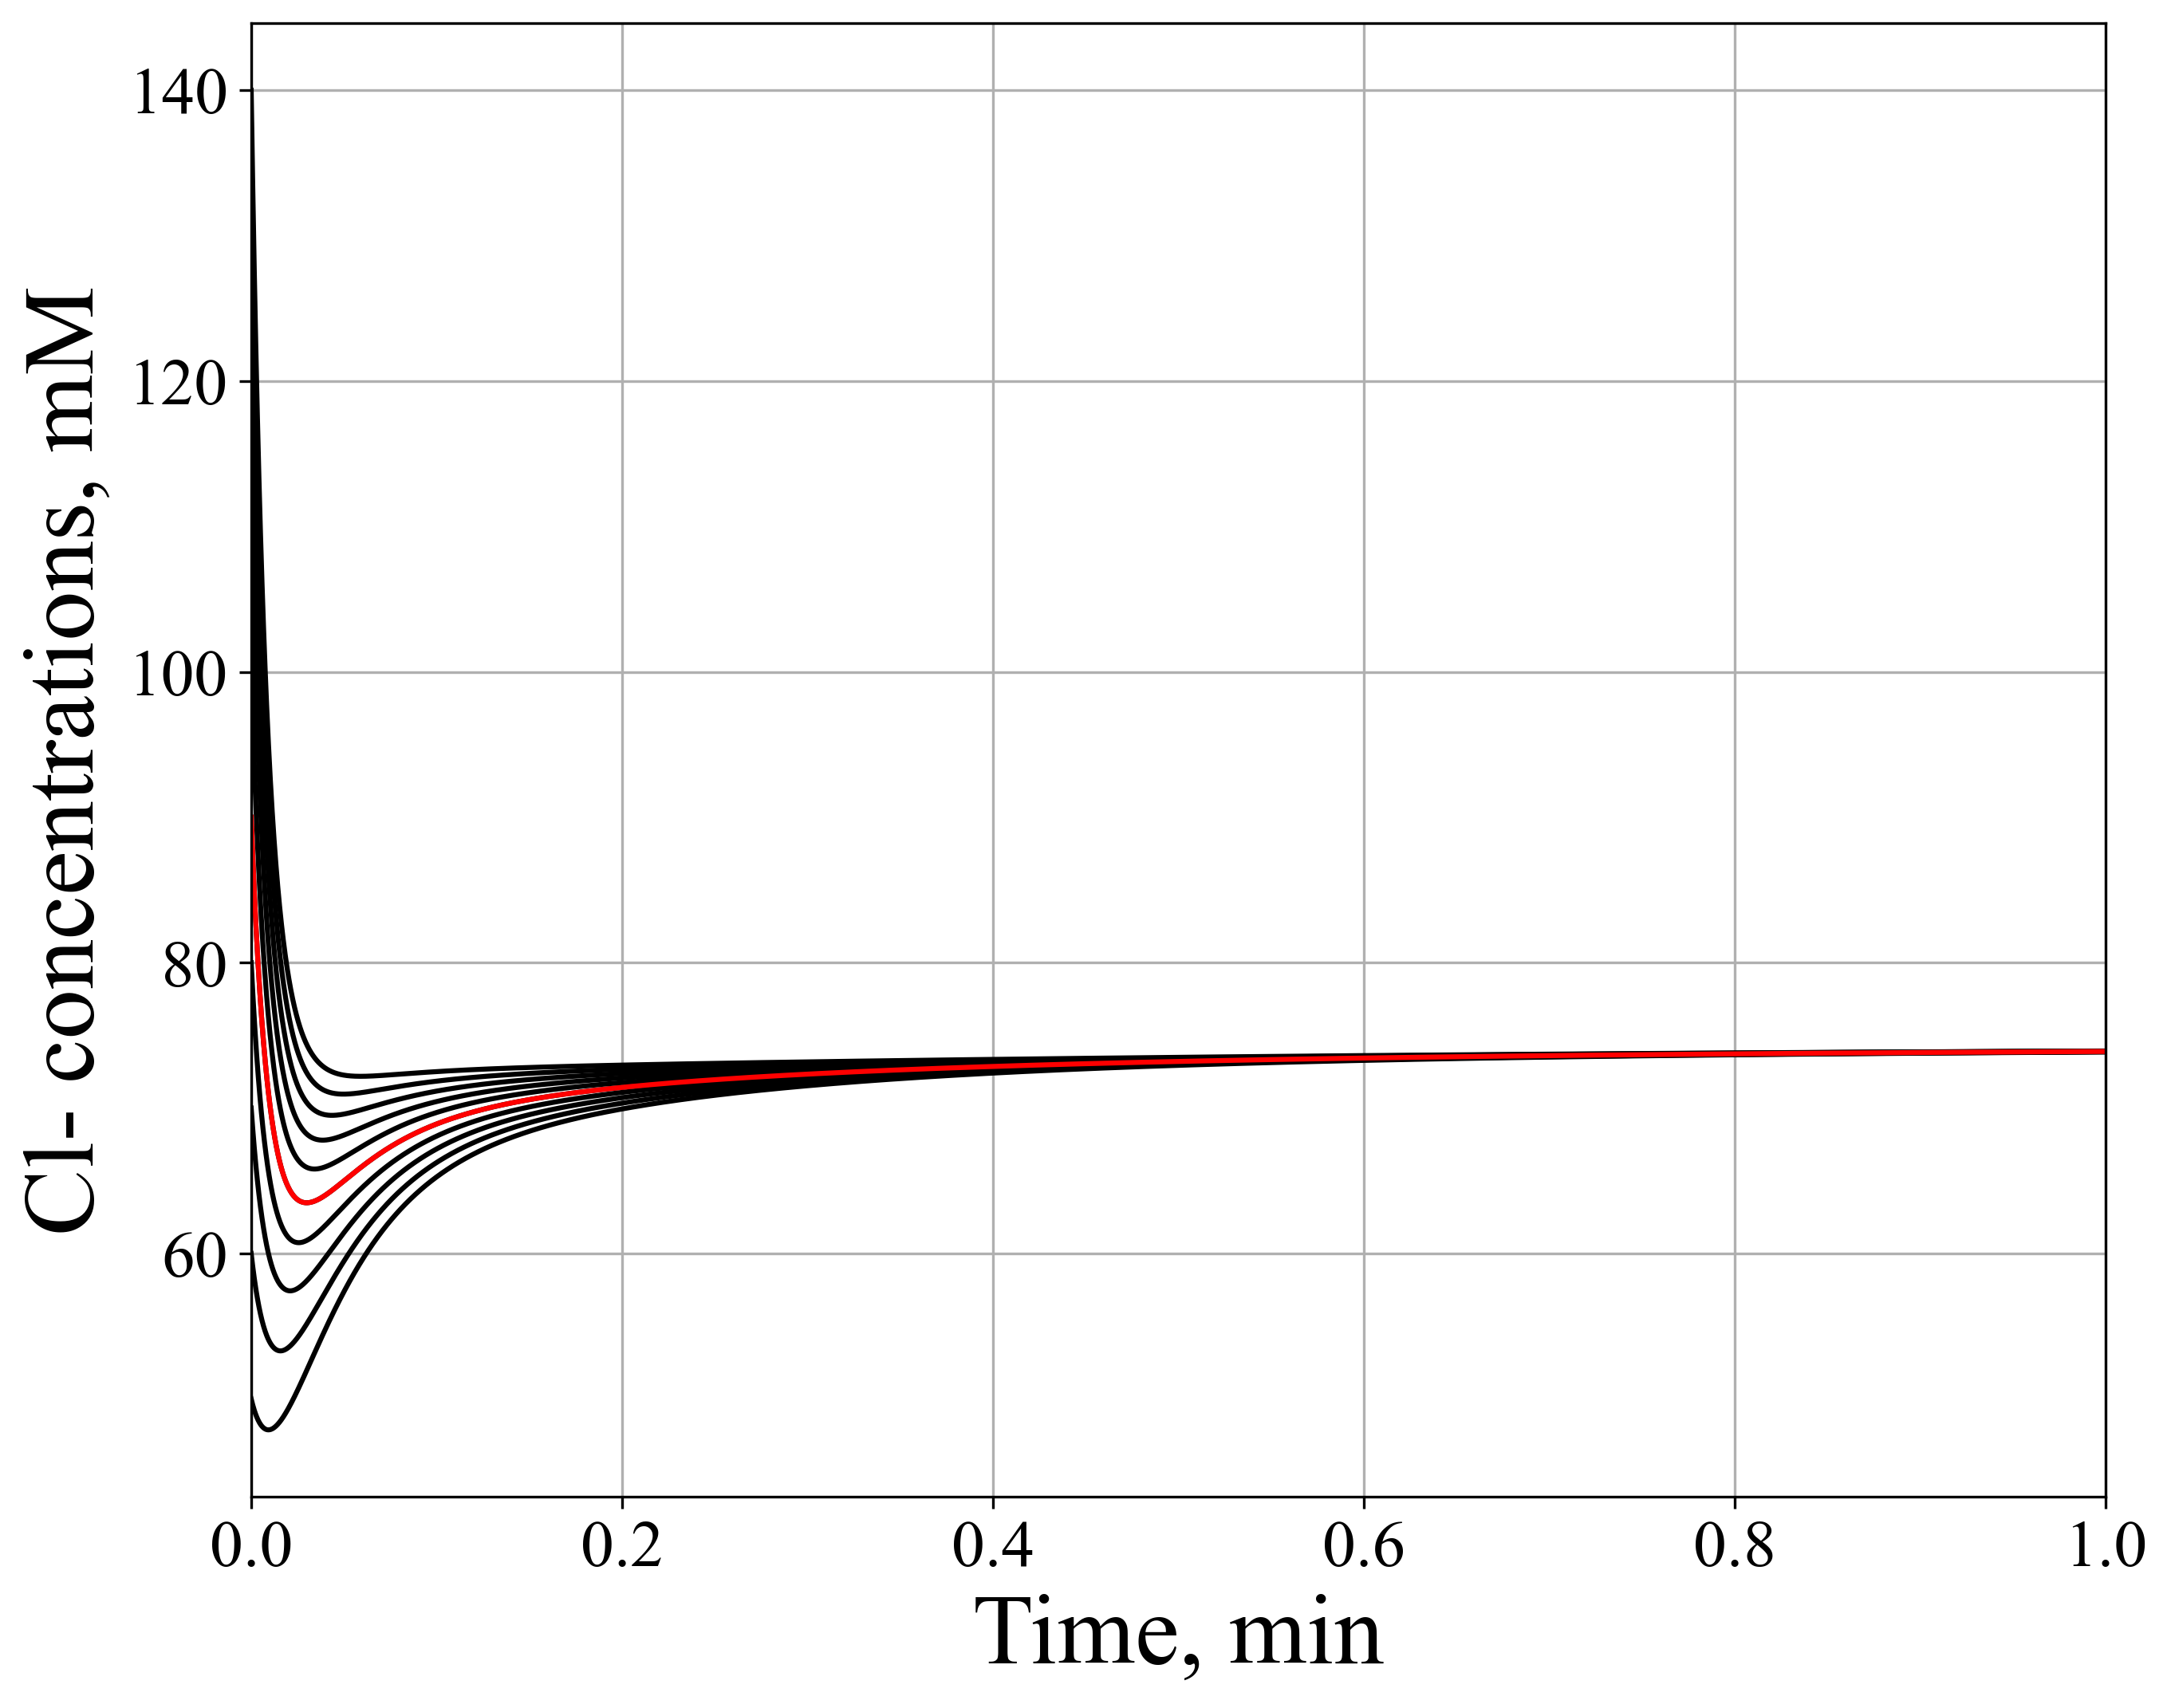

In [26]:
Cl_list = []
pH_list = []
R_list = []
vATPase_list = []

# Na_i = np.arange(0.09-0.09*0.1, 0.09+0.09*0.1, 0.09*0.2/5)
Cl_i = np.arange(50, 150, 10)/1000
Cl_i = np.append(Cl_i, 0.09)

for init_Cl_i in Cl_i:
    init_pH = 4.7
    init_Na = 0.09
    init_K = 0.04

    init_NH = np.power(10, -init_pH)*init_V*NA;      #[ions]
    init_NK = init_K*init_V*NA;       
    init_NNa = init_Na*init_V*NA;    
    init_NCl = init_Cl_i*init_V*NA;     
    init_NCa_T = init_Ca_T*init_V*NA; 
    init_NCa_F = init_Ca_F*init_V*NA; 

    X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

    tspan = np.arange(0, 600, 1e-2)
    solution = odeint(derivatives, X0, tspan)
    v_arr = V_arr_def(solution)
    Cl_list.append(solution[:, 5]/v_arr/NA)



def plot_Cl_list(t, Cl_list, Cl_i):
    t=t/60
    plt.figure(figsize=(10, 8), dpi=300)
    for i, Cl_in_list in enumerate(Cl_list):
        color_Cl = 'black'
        if i == len(Cl_i)-1:
            color_Cl = 'red'
        plt.plot(t, Cl_in_list*1000, color_Cl, label=f'Cl = {round(Cl_i[i], 1)}')
    # plt.ylim(0.03825, 0.03875)
    plt.xlim(0, 1)

    plt.ylabel('Cl- concentrations, mM', fontsize=30)
    plt.xlabel('Time, min', fontsize=30)
    # plt.legend(loc='best', fontsize=30)
    plt.grid()
    plt.savefig('figs/Cl_dif_Cl.png', dpi=300)
    plt.show()

plot_Cl_list(tspan, Cl_list, Cl_i)